### Imports

In [11]:
!gdown https://drive.google.com/file/d/1enUP9qsTiP3lQe1LRm1c9lMGUJ3q3MxO/view?usp=drive_link -O /content/test.fits

/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=1enUP9qsTiP3lQe1LRm1c9lMGUJ3q3MxO
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1enUP9qsTiP3lQe1LRm1c9lMGUJ3q3MxO/view?usp=drive_link
To: /content/test.fits
8.89kB [00:00, 19.0MB/s]


In [2]:
import numpy as np                           # for math and array operations
import matplotlib.pyplot as plt              # for plotting
from astropy.io import fits                  # for fits file handling
from scipy.optimize import curve_fit         # for model fitting
import pandas as pd

### Loading and inspecting fits file

We first load our data into Python. This time, the spectrum is in fits (Flexible Image Transport System) format, a widely used file type in astronomy. We inspect the file and its contents.

In [18]:
filename = "/content/test.fits"

hdul = fits.open(filename)
data = hdul[1].data
hdul.close()

OSError: No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True

In [19]:
hdul.info()

Filename: /content/test.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     143   ()      
  1  COADD         1 BinTableHDU     26   3832R x 8C   [E, E, E, J, J, E, E, E]   


In [20]:
hdr=hdul[1].header
hdr

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   32 / length of dimension 1                          
NAXIS2  =                 3832 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    8 / number of table fields                         
TTYPE1  = 'flux    '                                                            
TFORM1  = 'E       '                                                            
TTYPE2  = 'loglam  '                                                            
TFORM2  = 'E       '                                                            
TTYPE3  = 'ivar    '        

In [21]:
first_ten_rows = data[:10]
print(first_ten_rows)

[(13.562425, 3.5812, 0.09887567, 0,       0, 1.0487611, 11.691943, 8.113382 )
 (14.345251, 3.5813, 0.11898088, 0,       0, 1.048546 , 11.481527, 7.8677197)
 (14.678204, 3.5814, 0.11977661, 0,       0, 1.0483252, 11.604475, 7.3773475)
 (12.125173, 3.5815, 0.12694009, 0,       0, 1.0481043, 11.862787, 7.400687 )
 (15.350232, 3.5816, 0.1262673 , 0,       0, 1.0478839, 12.143755, 7.9414134)
 (12.767057, 3.5817, 0.13250898, 0,       0, 1.0476636, 12.394942, 7.6859326)
 ( 9.232386, 3.5818, 0.1365898 , 0,       0, 1.0474442, 12.627659, 8.040323 )
 ( 8.463278, 3.5819, 0.1390465 , 0, 1048576, 1.0472238, 12.852712, 8.063765 )
 ( 9.959573, 3.582 , 0.13613166, 0, 1048576, 1.0470021, 12.921357, 7.72469  )
 (15.200464, 3.5821, 0.13005757, 0,       0, 1.0467823, 12.975162, 7.613251 )]


### Plotting the full spectrum

Now that we have our data loaded, we plot the spectrum to see how it looks like.

In [22]:
flux = data["FLUX"]
loglam = data["LOGLAM"]
wave = 10.0 ** loglam
model = data["MODEL"]

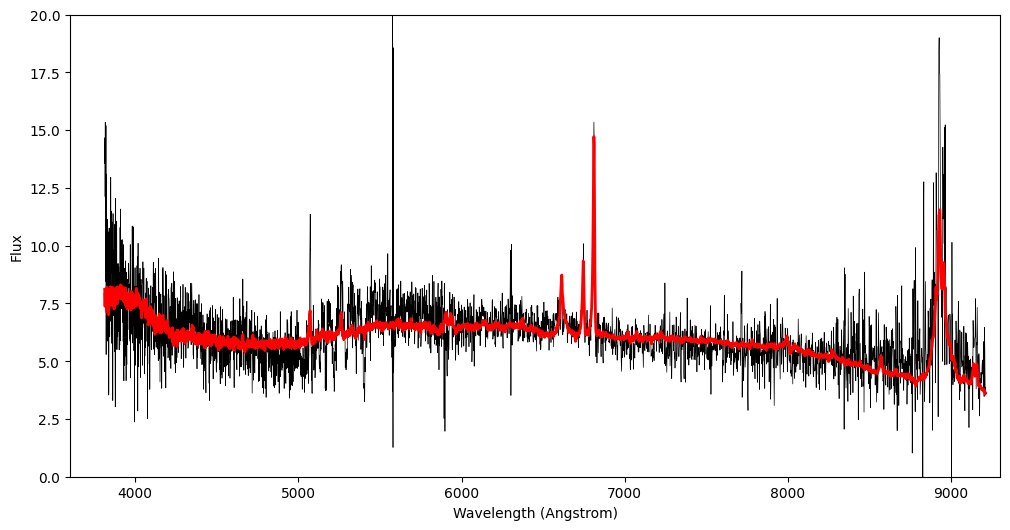

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(wave, flux, linewidth=0.5,color='black')
plt.plot(wave, model, linewidth=2,color='red')

plt.xlim(3600, 9300)
plt.ylim(0, 20)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")

plt.show()

### Estimating redshifted line positions

Given below are the rest frame wavelengths of a few prominent spectral lines.

In [24]:
Ha0 = 6562.7
Hb0  = 4861.3
OII0 = 3727.3
OIII10 = 4959.0
OIII20 = 5007.0
NeIII0 = 3869.0

We overplot these rest frame wavelengths on our spectrum to see if there are any matches.

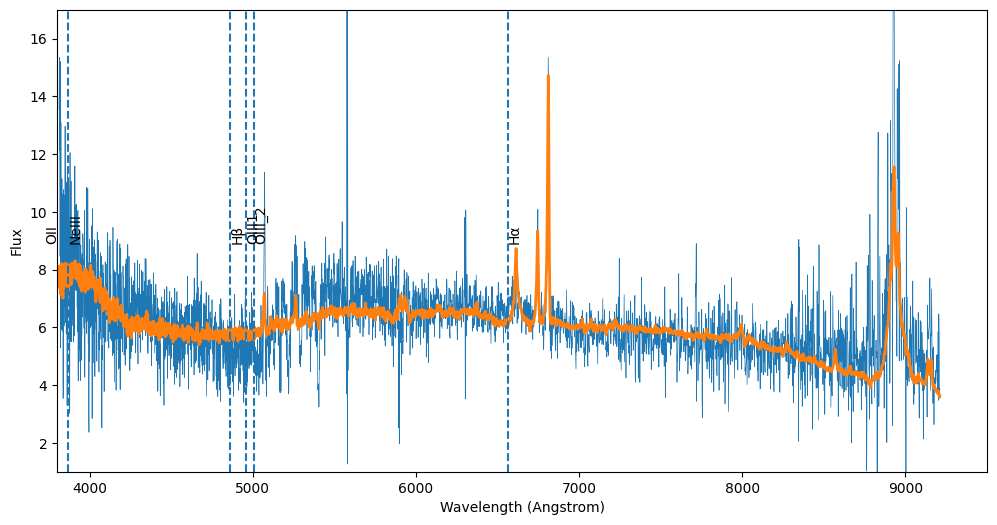

In [25]:
plt.figure(figsize=(12, 6))

plt.plot(wave, flux, linewidth=0.5)
plt.plot(wave, model, linewidth=2)

plt.xlim(3800, 9500)
plt.ylim(1, 17)

for line_wave, label in zip([Ha0, Hb0, OII0, OIII10, OIII20, NeIII0],
                            ["Hα", "Hβ", "OII", "OIII1", "OIII_2", "NeIII"]):
    plt.axvline(line_wave, linestyle="--")
    plt.text(line_wave, 9, label, rotation=90)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")

plt.show()

We now use Hubble's law with the distance to the galaxy (found using other methods) and an estimate of the Hubble's constant to get an estimate of where the lines should appear after accounting for redshift.

In [26]:
H0standard = 67.4       # km/s/Mpc
distance   = 1597.44    # Mpc
c = 3e5                 # km/s

lamb0 = np.array([6562.7, 4861.3,
                  3727.3, 4959.0, 5007.0,
                  3869.0])

lines = ["Halpha", "Hbeta",
         "OII", "OIII1", "OIII2",
         "NeIII"]

z_pred = (H0standard * distance) / c
plamb = lamb0 * (1 + z_pred)

print("Line   Predicted      Rest     Difference")
for name, pred, rest in zip(lines, plamb, lamb0):
    print(name, pred, rest, pred - rest)

Line   Predicted      Rest     Difference
Halpha 8917.997378304 6562.7 2355.2973783040006
Hbeta 6605.979346176 4861.3 1744.6793461759999
OII 5064.996362496 3727.3 1337.696362496
OIII1 6738.74304768 4959.0 1779.74304768
OIII2 6803.96984064 5007.0 1796.9698406400003
NeIII 5257.55129088 3869.0 1388.5512908800001


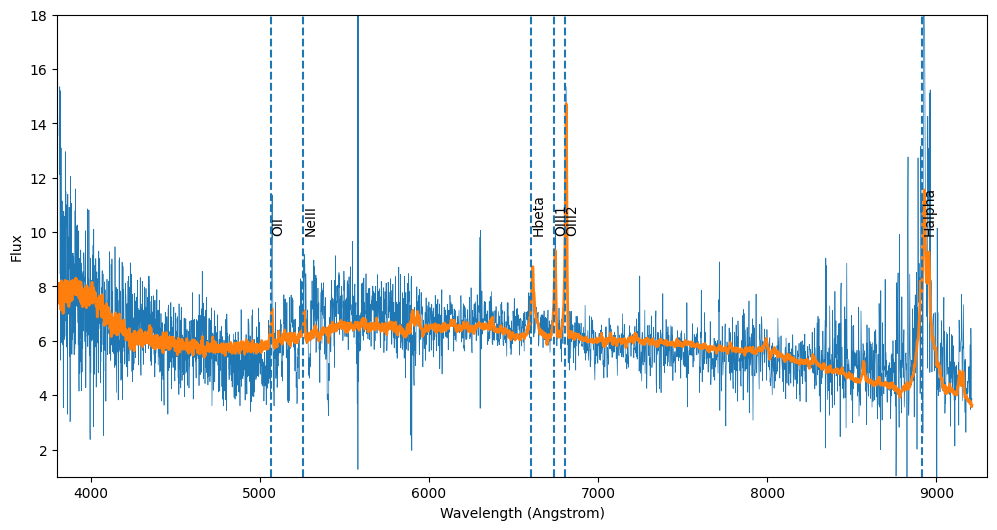

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(wave, flux, linewidth=0.5)
plt.plot(wave, model, linewidth=2)

plt.xlim(3800, 9300)
plt.ylim(1, 18)

for pw, name in zip(plamb, lines):
    plt.axvline(pw, linestyle="--")
    plt.text(pw, 10, name, rotation=90)

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")

plt.show()

### Continuum subtraction and line fitting

Now that we have identified the lines, we move forward with continuum subtraction and gaussian line fitting.

In [ ]:
cond_bkg = (wave >= plamb[0]-150) & (wave <= plamb[0]-50)
mean_bkg_model = np.mean(model[cond_bkg])

print("background flux:", mean_bkg_model)

In [ ]:
center_guess = plamb[0]  # predicted Halpha

cond = (wave >= center_guess - 140) & (wave <= center_guess + 140)

H_wave = wave[cond]
H_flux = flux[cond] - mean_bkg_model
H_model = model[cond] - mean_bkg_model

In [ ]:
def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [ ]:
initial_guess = [10.0, plamb[0], 10.0]

popt, pcov = curve_fit(gaussian, H_wave, H_model, p0=initial_guess)

amp_fit, mu_fit, sigma_fit = popt

print("---- Fit parameters ----")
print("Amplitude:", amp_fit)
print("Center:", mu_fit)
print("Sigma:", sigma_fit)

In [ ]:
plt.figure(figsize=(8.5, 5.5))

plt.plot(H_wave, H_flux, '.', markersize=3)
plt.plot(H_wave, H_model, linewidth=2)

x_fit = np.linspace(min(H_wave), max(H_wave), 500)
plt.plot(x_fit, gaussian(x_fit, *popt), linewidth=3)

plt.axvline(plamb[0], linestyle="--")
plt.axvline(mu_fit, linestyle="--",color='red')

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")

plt.show()

Now that we have the fitted line center, we can calculate the redshift and velocity.

In [ ]:
Ha_shifted = mu_fit

Ha_redshift = (Ha_shifted - lamb0[0]) / lamb0[0]
Velocity = 3e5 * Ha_redshift

print("Ha-shifted:", Ha_shifted)
print("Rest Halpha:", lamb0[0])
print("Shift:", Ha_shifted - lamb0[0])
print("Velocity (km/s):", Velocity)
print("Redshift:", Ha_redshift)

### DIY!

In this section, you have to fit the other lines in the spectrum using the above process. Given below are the predicted and rest frame wavelengths of the lines to use.

In [ ]:
df = pd.DataFrame({
    "Line": lines,
    "Predicted": plamb,
    "Rest": lamb0,
})

df["Difference"] = df["Predicted"] - df["Rest"]

# Print nicely
df

In [ ]:
cond_bkg = (wave >= 'center wavelength'-150) & (wave <= 'center wavelength'-50)
mean_bkg_model = np.mean(model[cond_bkg])

print("background flux:", mean_bkg_model)

In [ ]:
center_guess =   # put predicted line center here

cond = (wave >= center_guess - 140) & (wave <= center_guess + 140)

H_wave = wave[cond]
H_flux = flux[cond] - mean_bkg_model
H_model = model[cond] - mean_bkg_model

In [ ]:
initial_guess = [10.0, 'put center wavelength', 10.0]

popt, pcov = curve_fit(gaussian, H_wave, H_model, p0=initial_guess)

amp_fit, mu_fit, sigma_fit = popt

print("---- Fit parameters ----")
print("Amplitude:", amp_fit)
print("Center:", mu_fit)
print("Sigma:", sigma_fit)

In [ ]:
plt.figure(figsize=(8.5, 5.5))

plt.plot(H_wave, H_flux, '.', markersize=3)
plt.plot(H_wave, H_model, linewidth=2)

x_fit = np.linspace(min(H_wave), max(H_wave), 500)
plt.plot(x_fit, gaussian(x_fit, *popt), linewidth=3)

plt.axvline(center_guess, linestyle="--")
plt.axvline(mu_fit, linestyle="--",color='red')

plt.xlabel("Wavelength (Angstrom)")
plt.ylabel("Flux")

plt.show()

In [ ]:
line_shifted = mu_fit
line_rest= 'put rest wavelength here'

line_redshift = (line_shifted - line_rest) / line_rest
Velocity = 3e5 * line_redshift

print("Line-shifted:", line_shifted)
print("Rest line:", line_rest)
print("Shift:", line_shifted - line_rest)
print("Velocity (km/s):", Velocity)
print("Redshift:", line_redshift)

In the cell below are two empty arrays. For each line that you fit, add the line name to the line array and the corresponding velocity to the velocity array. Run the cell once all lines are done and you'll get the average velocity for the galaxy, along with the standard deviation.

In [ ]:
line=[]
velocity=[]

Mean_vel=np.mean(velocity)
Dev_vel=np.std(velocity)

print("Mean velocity:", Mean_vel)
print("Standard deviation:", Dev_vel)

### Hubble's Law

In [ ]:
data=pd.read_csv('/content/galaxy_distances_velocities.csv')
df=pd.DataFrame(data)
df

In [ ]:
plt.figure(figsize=(9, 6))
plt.errorbar(df['Distance_Mpc'], df['Velocity_km_s'], yerr=df['Velocity_Error_km_s'], fmt='o', markersize=7)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Galaxy Distances and Velocities')
plt.show()

In [ ]:
d = df['Distance_Mpc'].values
v = df['Velocity_km_s'].values
v_err = df['Velocity_Error_km_s'].values

# Defining linear model
def hubble_law(d, H0):
    return H0 * d

# Initial guess for Hubble's constant
p0 = [70.0]

popt, pcov = curve_fit(
    hubble_law,
    d,
    v,
    sigma=v_err,
    absolute_sigma=True,
    p0=p0
)

H0_fit = popt[0]
H0_err = np.sqrt(pcov[0, 0])

print("----- Estimated Hubble Constant -----")
print(f"H0 = {H0_fit:.3f} ± {H0_err:.3f} km/s/Mpc")

In [ ]:
d_fit = np.linspace(0, max(d)*1.1, 100)
v_fit = hubble_law(d_fit, H0_fit)

plt.figure(figsize=(9, 6))
plt.errorbar(d, v, yerr=v_err, fmt='o', markersize=7)
plt.plot(d_fit, v_fit)
plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.text(0.55, 0.15,
         f"Estimated Hubble's Constant\n$H_0$ = {H0_fit:.3f} ± {H0_err:.3f} km/s/Mpc",
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="grey", alpha=0.4))
plt.title("Hubble's Law Graph with Estimated $H_0$ made by [Your name]")
plt.show()